# Week 8: Unsupervised Clustering

## What is unsupervised learning?

So far in this course, we have mostly worked with **supervised learning** — we had a set of inputs and a known output (a label or a target value), and the goal was to learn the relationship between them.

**Unsupervised learning** is different: there are no labels. We are not trying to predict anything in particular. Instead, we are looking for hidden structure in the data itself — groups, patterns, or compressed representations that the data naturally contains.

This makes unsupervised learning harder and more open-ended. There is no "right answer" to check against, so evaluating results requires judgment and domain knowledge. Think of it as exploratory — you are asking the data "what's interesting here?" rather than "can you predict this?"

Common use cases include:
- Finding groups of cancer patients with similar gene expression profiles
- Grouping shoppers by browsing and purchase behavior
- Organizing search engine results into topic clusters

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

## Clustering

**Clustering** is the task of grouping observations so that points within a group are similar to each other and points in different groups are quite different from each other.

That sounds straightforward, but the hard part is: what does "similar" mean? If you are looking at customers, does similar mean they bought the same things, spent the same amount, or visited the store around the same times? The choice of similarity measure shapes the results, and there is no universally correct answer.

The two most widely used clustering approaches are:
- **K-means clustering** — fast, simple, and widely applicable
- **Hierarchical clustering** — builds a tree of relationships you can explore at different levels of detail

## K-means Clustering

K-means is probably the most common clustering algorithm. Here is the core idea:

1. You decide in advance how many clusters you want — call that number K.
2. The algorithm randomly places K cluster centers somewhere in the data space.
3. Every data point is assigned to whichever center is closest to it.
4. Each center then moves to the average position of all the points assigned to it.
5. Steps 3 and 4 repeat until the assignments stop changing.

The result is K non-overlapping clusters that collectively cover every data point. Each cluster is defined by its center (called the **centroid**), and the algorithm minimizes the total spread of points around their centers.

One important caveat: because the centers start in random positions, you can get different results each time you run the algorithm. The standard practice is to run it many times with different random starts and keep the best result. The `n_init` parameter in scikit-learn controls how many restarts to try.

Below we generate some synthetic data with 5 natural clusters and then apply K-means.

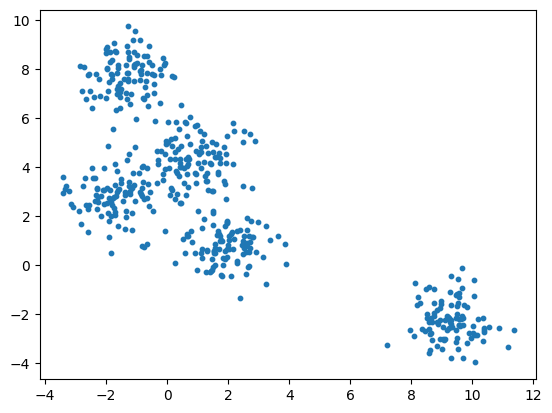

In [3]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples = 500, centers = 5, cluster_std = 0.8, random_state = 0)
plt.scatter(X[:,0], X[:,1], s=10)

In [4]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, n_init=10)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

KMeans(n_clusters=5, n_init=10)

In [5]:
y_kmeans

array([2, 0, 0, 4, 0, 1, 0, 1, 2, 2, 3, 4, 0, 3, 4, 1, 4, 1, 0, 4, 2, 1,
       4, 4, 2, 3, 2, 2, 3, 4, 2, 0, 0, 3, 0, 2, 2, 1, 1, 1, 3, 1, 4, 4,
       0, 0, 1, 0, 2, 3, 0, 1, 2, 2, 1, 0, 1, 1, 3, 4, 2, 1, 2, 4, 0, 3,
       0, 3, 0, 0, 0, 2, 4, 1, 0, 0, 2, 2, 4, 2, 4, 3, 0, 0, 1, 2, 1, 0,
       0, 4, 4, 3, 3, 4, 1, 2, 2, 4, 3, 0, 2, 3, 3, 2, 0, 4, 1, 2, 2, 0,
       0, 4, 2, 1, 1, 3, 3, 3, 2, 1, 1, 4, 0, 3, 4, 0, 1, 4, 3, 3, 3, 2,
       0, 1, 3, 1, 1, 1, 0, 4, 2, 3, 2, 4, 2, 1, 1, 3, 2, 0, 0, 3, 3, 2,
       0, 0, 0, 0, 3, 4, 3, 1, 4, 0, 2, 2, 4, 2, 1, 2, 4, 0, 1, 1, 2, 3,
       4, 3, 0, 3, 0, 3, 3, 1, 4, 1, 2, 0, 3, 1, 3, 2, 1, 0, 2, 4, 0, 1,
       3, 3, 2, 3, 0, 3, 3, 2, 1, 4, 4, 0, 1, 3, 0, 3, 1, 3, 1, 2, 2, 0,
       2, 4, 1, 1, 1, 0, 4, 1, 1, 4, 2, 4, 0, 3, 3, 0, 3, 4, 1, 0, 2, 0,
       3, 1, 2, 2, 3, 3, 2, 1, 1, 0, 2, 2, 0, 0, 4, 0, 4, 3, 1, 4, 3, 2,
       0, 4, 1, 2, 4, 0, 0, 3, 4, 2, 3, 2, 3, 2, 3, 3, 4, 2, 2, 2, 0, 2,
       3, 4, 3, 1, 4, 0, 0, 0, 2, 1, 3, 4, 1, 3, 1,

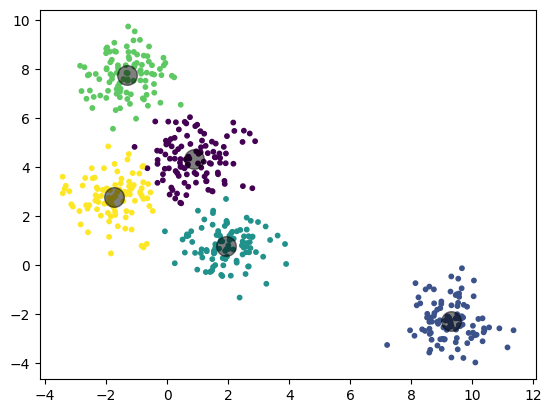

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=10, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

The scatter plot above shows each point colored by its assigned cluster, with the black dots marking the cluster centers. Notice how the algorithm has found the five natural groupings that were built into this synthetic dataset.

### A limitation: K-means can only find roughly spherical clusters

K-means measures distance from each point to each center using straight-line (Euclidean) distance, which means the cluster boundaries it draws are always straight lines. This works great when your clusters are blob-shaped, but it breaks down when the underlying structure is curved or interlocking.

The next example uses a dataset shaped like two crescent moons — a shape K-means simply cannot capture correctly. We then try **spectral clustering**, which uses the connectivity structure of the data rather than raw distances, and can handle these non-linear shapes.

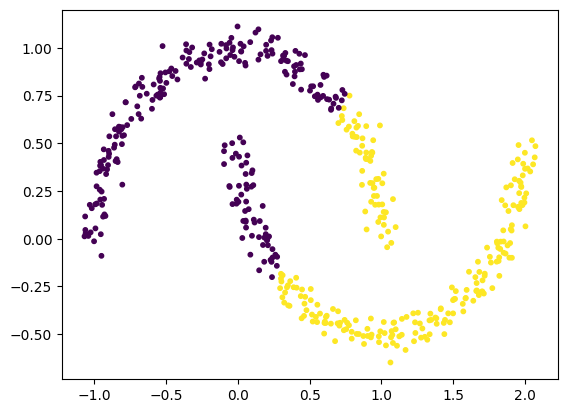

In [7]:
from sklearn.datasets import make_moons
X, y = make_moons(500, noise=.05, random_state=0)

labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=10, cmap='viridis');

/Users/chelseatroy/.pyenv/versions/3.10.8/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


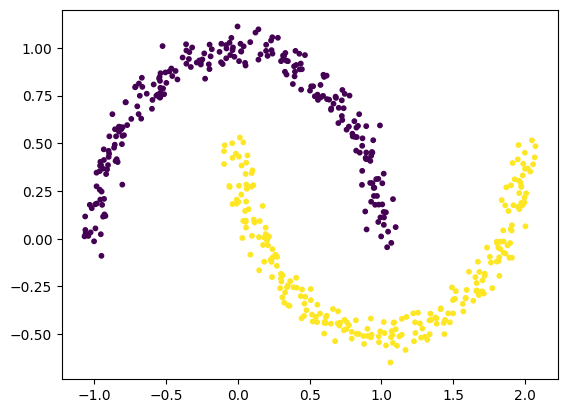

In [8]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=10, cmap='viridis');

### An unexpected application: image color compression

Here is a fun application of K-means that illustrates how broadly clustering can be used. A photograph stores a color for every pixel, and each color is represented as three numbers (red, green, blue). A typical image has millions of distinct colors.

What if we want to compress the image by reducing it to just 16 colors? We can treat each pixel's color as a data point in 3D space (one dimension per color channel) and run K-means with K=16. Each pixel is then replaced with the nearest cluster center — meaning one of only 16 representative colors.

This is lossy compression: the image will look slightly different, but often the result is surprisingly close to the original. The K-means algorithm finds the 16 colors that best represent the full range of colors in the image.

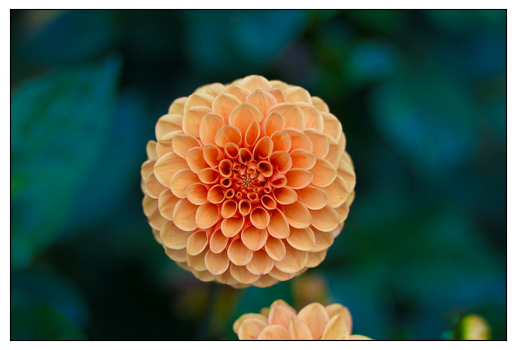

In [9]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower)

In [10]:
flower.shape

(427, 640, 3)

In [11]:
# This is an array of 427x640 pixels, and for each pixel,
# we have three values between 0 and 255,
# one for red, one for green, and one for blue.
# We will reshape it for our purposes.

data = flower / 255.0
data = data.reshape(flower.shape[0] * flower.shape[1], flower.shape[2])
data.shape

(273280, 3)

In [12]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

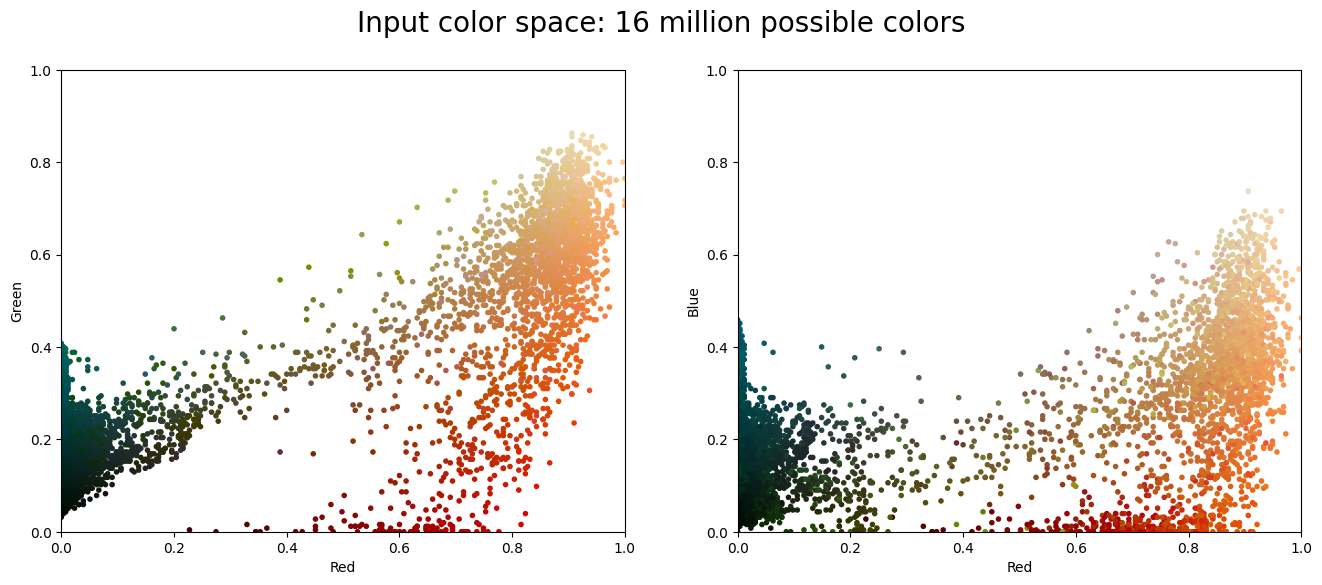

In [13]:
plot_pixels(data, title='Input color space: 16 million possible colors')

KMeans(n_clusters=16, n_init=10)

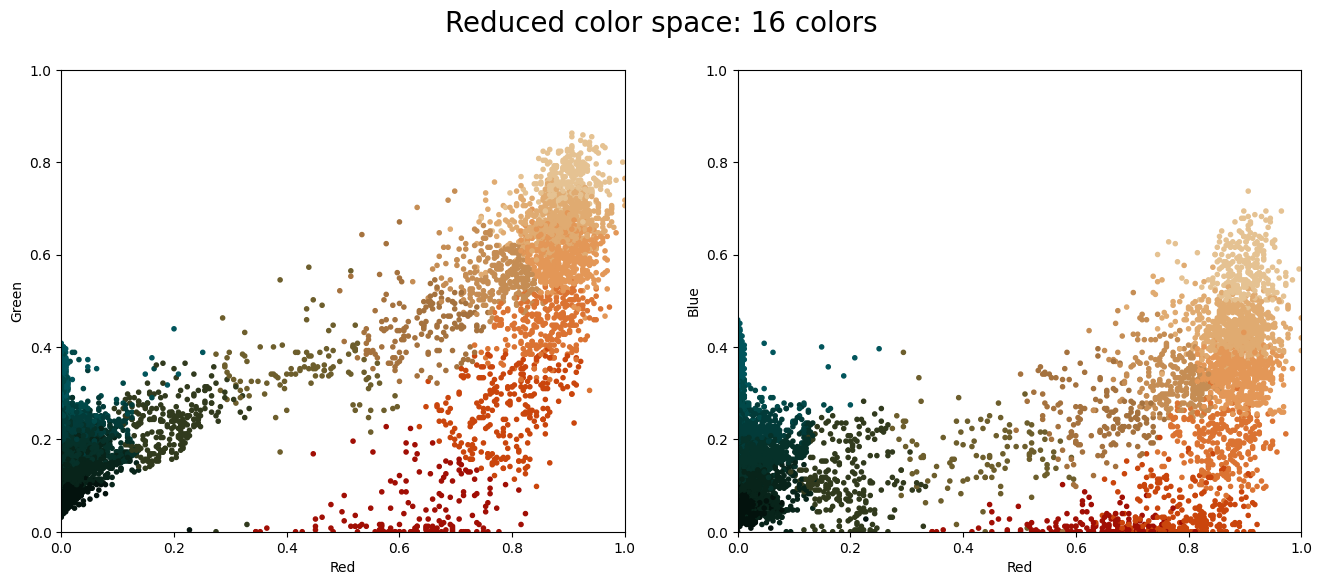

In [14]:
#from sklearn.cluster import MiniBatchKMeans
kmeans = KMeans(n_clusters=16, n_init=10)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors, title="Reduced color space: 16 colors")

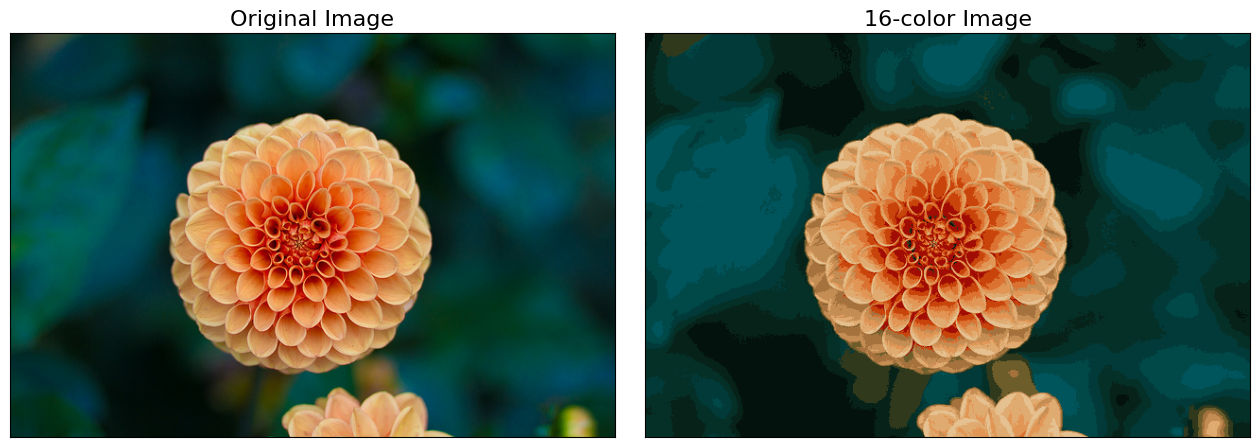

In [15]:
flower_recolored = new_colors.reshape(flower.shape)
fig, ax = plt.subplots(1, 2, figsize=(16, 6), subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

The side-by-side comparison above shows the original image alongside the version that uses only 16 colors. The structural content is preserved remarkably well. This is because the most important visual information is carried by the dominant colors, and K-means efficiently finds those dominant colors.

### Choosing K: how many clusters is the right number?

In the examples above, we chose K based on our knowledge of the data (we knew there were 5 blobs, 2 moons, or 16 colors we wanted). In practice, you usually do not know K in advance.

A common technique for choosing K is the **elbow method**: run K-means for several different values of K (say, 1 through 10), and for each run record the total within-cluster variance — that is, how spread out points are around their cluster centers. As K increases, this variance always decreases (more clusters means each one is tighter). But at some point, adding another cluster stops helping much. Plotting the variance against K, you look for an "elbow" in the curve — the point where the gains start to flatten out. That elbow suggests a good value of K.

Use the slider below to explore different values of K on the synthetic blob data.

In [16]:
import ipywidgets as widgets
from IPython.display import display

X_blob, _ = make_blobs(n_samples=500, centers=5, cluster_std=0.8, random_state=0)

def plot_elbow_and_clusters(k):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: elbow plot
    k_max = 10
    inertias = []
    for ki in range(1, k_max + 1):
        km = KMeans(n_clusters=ki, n_init=10, random_state=0)
        km.fit(X_blob)
        inertias.append(km.inertia_)
    axes[0].plot(range(1, k_max + 1), inertias, marker='o')
    axes[0].axvline(x=k, color='red', linestyle='--', label=f'Selected K={k}')
    axes[0].set_xlabel('Number of clusters (K)')
    axes[0].set_ylabel('Total within-cluster variance')
    axes[0].set_title('Elbow Method')
    axes[0].legend()

    # Right: cluster plot for chosen k
    km_chosen = KMeans(n_clusters=k, n_init=10, random_state=0)
    labels = km_chosen.fit_predict(X_blob)
    axes[1].scatter(X_blob[:, 0], X_blob[:, 1], c=labels, s=10, cmap='viridis')
    centers = km_chosen.cluster_centers_
    axes[1].scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
    axes[1].set_title(f'K-means with K={k}')

    plt.tight_layout()
    plt.show()

k_slider = widgets.IntSlider(value=5, min=1, max=10, step=1, description='K:')
widgets.interact(plot_elbow_and_clusters, k=k_slider)

interactive(children=(IntSlider(value=5, description='K:', max=10, min=1), Output()), _dom_classes=('widget-in…

<function __main__.plot_elbow_and_clusters(k)>

## Hierarchical Clustering

The biggest drawback of K-means is that you have to decide on K before you start. What if you are genuinely unsure how many groups exist in your data?

**Hierarchical clustering** sidesteps this problem entirely. Instead of picking K, it builds a tree — called a **dendrogram** — that shows the full nesting structure of the data. You can then cut the tree at any height to get whatever number of clusters you want, and you can visualize the whole hierarchy at once.

The most common variant is **agglomerative** (or "bottom-up") clustering:

1. Start with every data point as its own cluster.
2. Find the two clusters that are closest to each other and merge them.
3. Repeat step 2 until everything has been merged into one big cluster.

The result is a tree where the leaves are individual data points, and each branch point represents a merge. The height of a branch point tells you how dissimilar the two groups were when they merged — lower merges mean more similar groups.

### What is linkage?

To merge clusters, we need to define the distance between two clusters (not just two points). This is called the **linkage criterion**, and the choice matters a lot:

- **Complete linkage**: the distance between two clusters is the distance between their two most distant members. This tends to produce compact, well-separated clusters.
- **Average linkage**: the distance is the average of all pairwise distances between the two clusters. A good middle-ground choice.
- **Single linkage**: the distance is between the two closest members. This can create long, chain-like clusters.
- **Centroid linkage**: the distance between the two clusters' center points.

Average and complete linkage generally produce the most balanced, interpretable dendrograms.

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
np.set_printoptions(precision=5, suppress=True)

(300, 2)


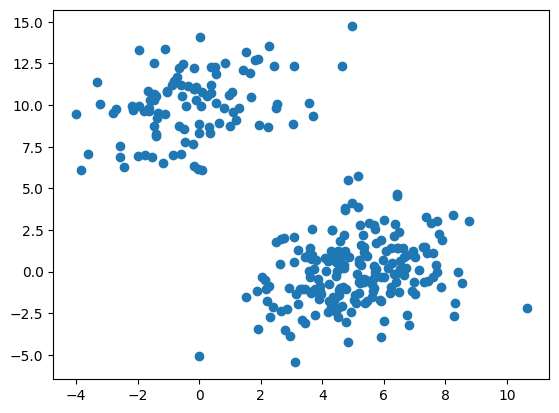

In [18]:
np.random.seed(42)
a = np.random.multivariate_normal([5, 0], [[3, 1], [1, 4]], size=[200,])
b = np.random.multivariate_normal([0, 10], [[3, 1], [1, 4]], size=[100,])
X = np.concatenate((a, b),)
print(X.shape)
plt.scatter(X[:,0], X[:,1])
plt.show()

We have 300 data points in two clusters (200 in group `a`, 100 in group `b`). We will now build the hierarchical clustering using average linkage. The `linkage()` function returns a matrix where each row describes one merge: which two clusters were merged, the distance at which they merged, and how many points are in the resulting cluster.

In [19]:
Z = linkage(X, 'average')
Z.shape

(299, 4)

In [20]:
Z[0]

array([277.    , 290.    ,   0.0056,   2.    ])

In [21]:
Z[1]

array([66.     , 91.     ,  0.02299,  2.     ])

In [22]:
Z[:30]

array([[277.     , 290.     ,   0.0056 ,   2.     ],
       [ 66.     ,  91.     ,   0.02299,   2.     ],
       [ 17.     ,  69.     ,   0.02481,   2.     ],
       [ 28.     , 168.     ,   0.03496,   2.     ],
       [ 43.     , 148.     ,   0.04743,   2.     ],
       [ 23.     , 112.     ,   0.05479,   2.     ],
       [150.     , 190.     ,   0.06476,   2.     ],
       [ 59.     , 163.     ,   0.06956,   2.     ],
       [ 34.     , 147.     ,   0.07442,   2.     ],
       [116.     , 166.     ,   0.07601,   2.     ],
       [246.     , 254.     ,   0.07768,   2.     ],
       [ 72.     ,  87.     ,   0.07878,   2.     ],
       [ 16.     , 177.     ,   0.08599,   2.     ],
       [ 49.     , 178.     ,   0.09768,   2.     ],
       [ 61.     , 135.     ,   0.09794,   2.     ],
       [203.     , 248.     ,   0.09869,   2.     ],
       [  6.     ,  18.     ,   0.10092,   2.     ],
       [187.     , 189.     ,   0.10093,   2.     ],
       [ 99.     , 113.     ,   0.10151,   2. 

In [23]:
cut_tree(Z, 3)

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
    

### Reading the dendrogram

The dendrogram is the main visualization for hierarchical clustering. Each vertical line at the bottom represents one data point. As you move upward, lines merge together at heights that reflect how dissimilar those groups were when combined.

To get a fixed number of clusters, you "cut" the dendrogram horizontally at some height. Everything that is joined below the cut belongs to one cluster. The `color_threshold` parameter in `dendrogram()` draws a horizontal cut line and colors the resulting clusters.

The key insight: you do not have to commit to a number of clusters before building the dendrogram. You explore the full tree and decide where to cut based on what you see. Use the slider below to interactively explore different cut heights.

<Figure size 2500x1000 with 0 Axes>

Text(0.5, 1.0, 'Hierarchical Clustering Dendrogram')

Text(0.5, 0, 'sample index')

Text(0, 0.5, 'distance')

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [85.0, 85.0, 95.0, 95.0],
  [62.5, 62.5, 90.0, 90.0],
  [45.0, 45.0, 76.25, 76.25],
  [30.0, 30.0, 60.625, 60.625],
  [115.0, 115.0, 125.0, 125.0],
  [105.0, 105.0, 120.0, 120.0],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [112.5, 112.5, 142.5, 142.5],
  [175.0, 175.0, 185.0, 185.0],
  [165.0, 165.0, 180.0, 180.0],
  [195.0, 195.0, 205.0, 205.0],
  [215.0, 215.0, 225.0, 225.0],
  [235.0, 235.0, 245.0, 245.0],
  [255.0, 255.0, 265.0, 265.0],
  [240.0, 240.0, 260.0, 260.0],
  [220.0, 220.0, 250.0, 250.0],
  [200.0, 200.0, 235.0, 235.0],
  [172.5, 172.5, 217.5, 217.5],
  [127.5, 127.5, 195.0, 195.0],
  [45.3125, 45.3125, 161.25, 161.25],
  [275.0, 275.0, 285.0, 285.0],
  [305.0, 305.0, 315.0, 315.0],
  [295.0, 295.0, 310.0, 310.0],
  [280.0, 280.0, 302.5, 302.5],
  [325.0, 325.0, 335.0, 335.0],
  [355.0, 355.0, 365.0, 365.0],
  [345.0, 345.0, 360

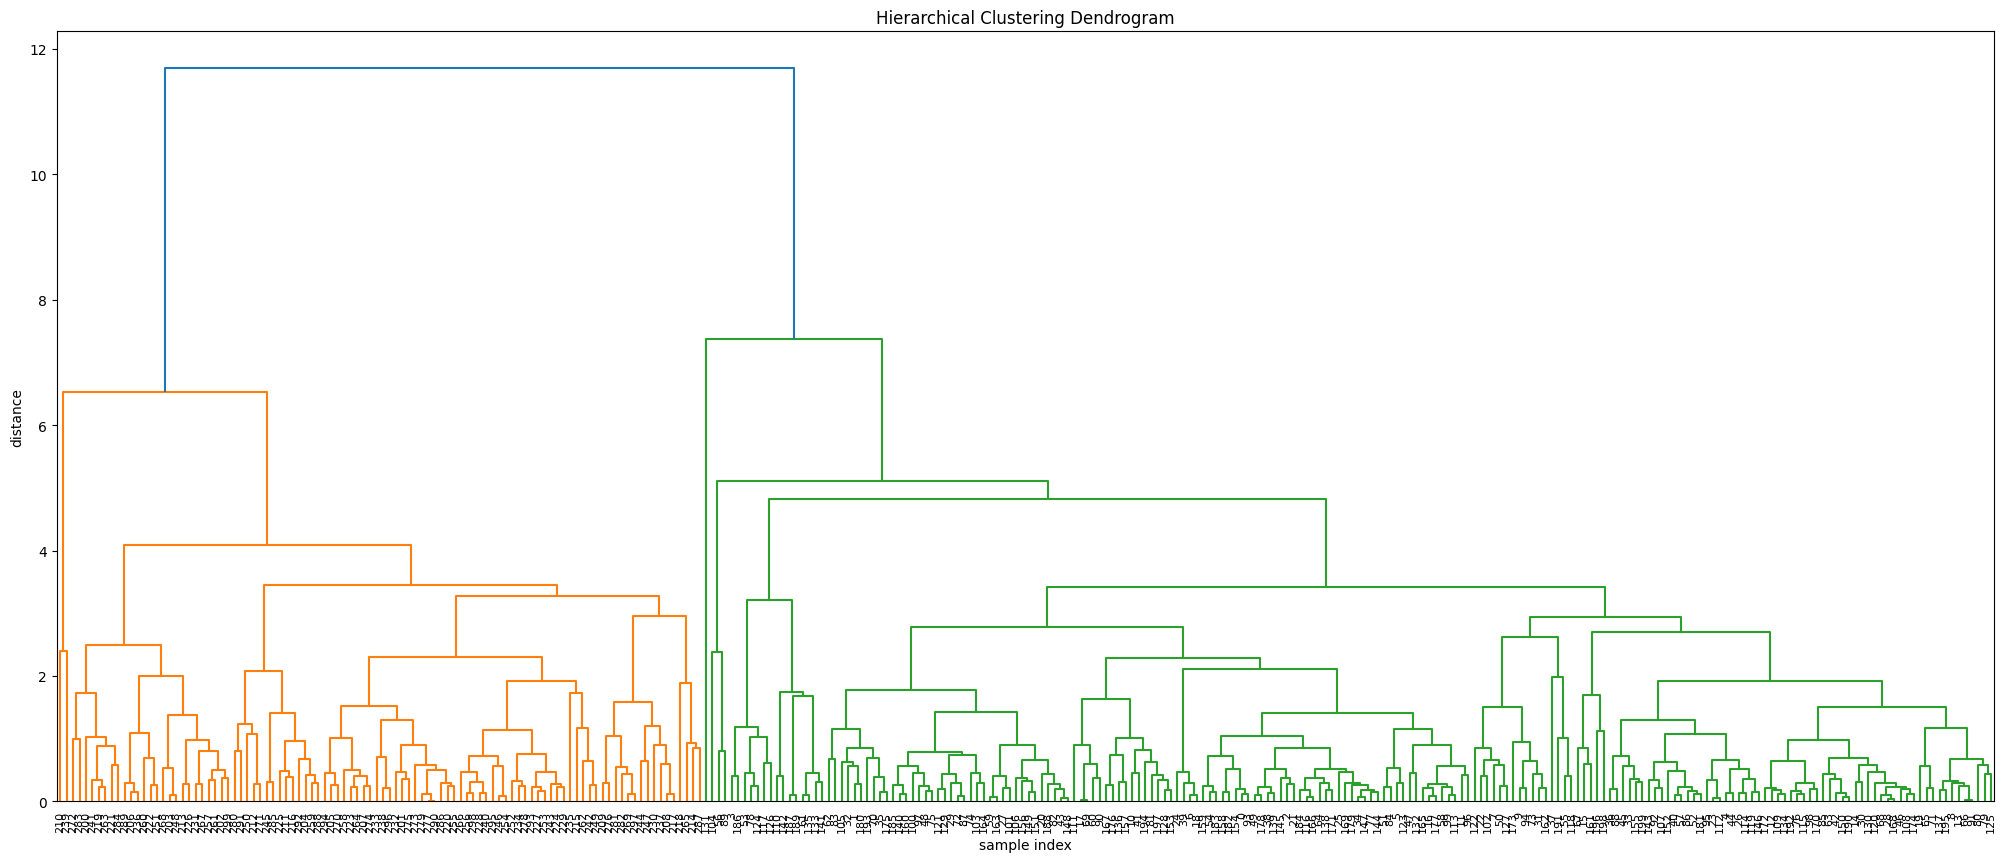

In [24]:
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.show()

In [25]:
def plot_dendrogram_interactive(color_threshold):
    plt.figure(figsize=(20, 7))
    plt.title('Hierarchical Clustering Dendrogram (interactive)')
    plt.xlabel('Sample index')
    plt.ylabel('Distance')
    dendrogram(Z, leaf_rotation=90, leaf_font_size=8, color_threshold=color_threshold)
    plt.axhline(y=color_threshold, color='gray', linestyle='--', alpha=0.5)
    plt.show()

threshold_slider = widgets.FloatSlider(value=8.0, min=0.1, max=12.0, step=0.1, description='Cut height:')
widgets.interact(plot_dendrogram_interactive, color_threshold=threshold_slider)

interactive(children=(FloatSlider(value=8.0, description='Cut height:', max=12.0, min=0.1), Output()), _dom_cl…

<function __main__.plot_dendrogram_interactive(color_threshold)>

<Figure size 2500x1000 with 0 Axes>

Text(0.5, 1.0, 'Hierarchical Clustering Dendrogram')

Text(0.5, 0, 'sample index')

Text(0, 0.5, 'distance')

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [85.0, 85.0, 95.0, 95.0],
  [62.5, 62.5, 90.0, 90.0],
  [45.0, 45.0, 76.25, 76.25],
  [30.0, 30.0, 60.625, 60.625],
  [115.0, 115.0, 125.0, 125.0],
  [105.0, 105.0, 120.0, 120.0],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [112.5, 112.5, 142.5, 142.5],
  [175.0, 175.0, 185.0, 185.0],
  [165.0, 165.0, 180.0, 180.0],
  [195.0, 195.0, 205.0, 205.0],
  [215.0, 215.0, 225.0, 225.0],
  [235.0, 235.0, 245.0, 245.0],
  [255.0, 255.0, 265.0, 265.0],
  [240.0, 240.0, 260.0, 260.0],
  [220.0, 220.0, 250.0, 250.0],
  [200.0, 200.0, 235.0, 235.0],
  [172.5, 172.5, 217.5, 217.5],
  [127.5, 127.5, 195.0, 195.0],
  [45.3125, 45.3125, 161.25, 161.25],
  [275.0, 275.0, 285.0, 285.0],
  [305.0, 305.0, 315.0, 315.0],
  [295.0, 295.0, 310.0, 310.0],
  [280.0, 280.0, 302.5, 302.5],
  [325.0, 325.0, 335.0, 335.0],
  [355.0, 355.0, 365.0, 365.0],
  [345.0, 345.0, 360

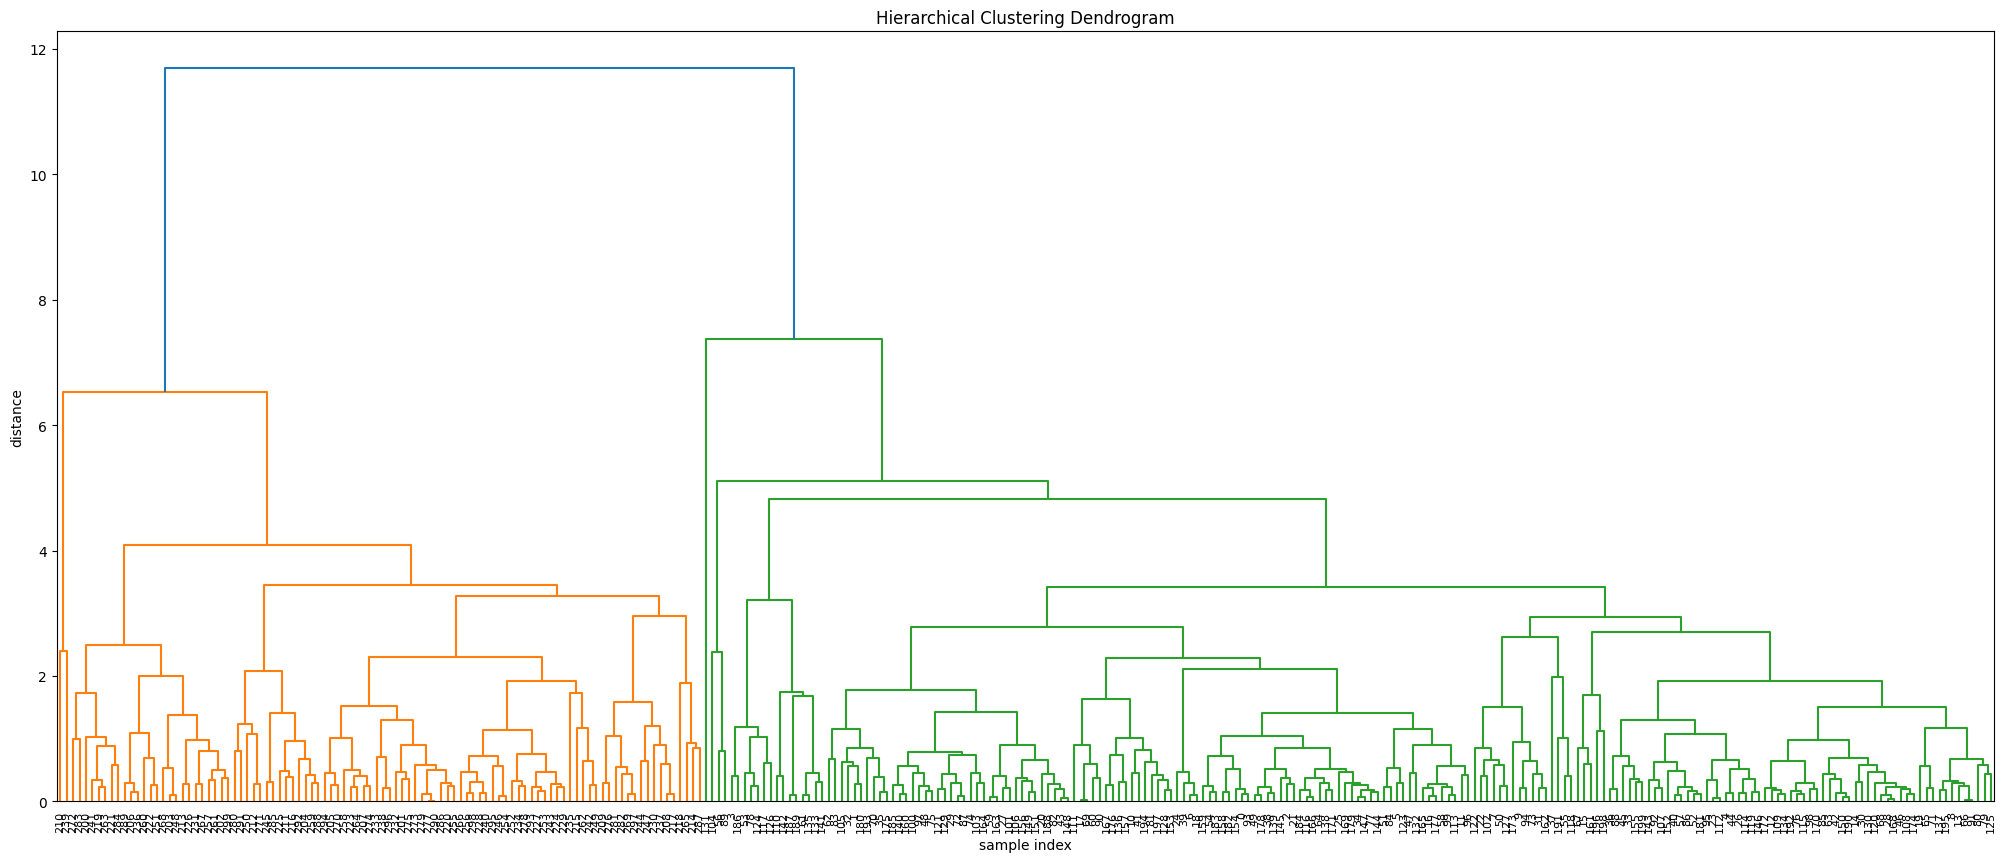

In [26]:
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(Z, leaf_rotation=90, leaf_font_size=8, color_threshold=8)
plt.show()

<Figure size 2500x1000 with 0 Axes>

Text(0.5, 1.0, 'Hierarchical Clustering Dendrogram')

Text(0.5, 0, 'sample index')

Text(0, 0.5, 'distance')

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [85.0, 85.0, 95.0, 95.0],
  [62.5, 62.5, 90.0, 90.0],
  [45.0, 45.0, 76.25, 76.25],
  [30.0, 30.0, 60.625, 60.625],
  [115.0, 115.0, 125.0, 125.0],
  [105.0, 105.0, 120.0, 120.0],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [112.5, 112.5, 142.5, 142.5],
  [175.0, 175.0, 185.0, 185.0],
  [165.0, 165.0, 180.0, 180.0],
  [195.0, 195.0, 205.0, 205.0],
  [215.0, 215.0, 225.0, 225.0],
  [235.0, 235.0, 245.0, 245.0],
  [255.0, 255.0, 265.0, 265.0],
  [240.0, 240.0, 260.0, 260.0],
  [220.0, 220.0, 250.0, 250.0],
  [200.0, 200.0, 235.0, 235.0],
  [172.5, 172.5, 217.5, 217.5],
  [127.5, 127.5, 195.0, 195.0],
  [45.3125, 45.3125, 161.25, 161.25],
  [275.0, 275.0, 285.0, 285.0],
  [305.0, 305.0, 315.0, 315.0],
  [295.0, 295.0, 310.0, 310.0],
  [280.0, 280.0, 302.5, 302.5],
  [325.0, 325.0, 335.0, 335.0],
  [355.0, 355.0, 365.0, 365.0],
  [345.0, 345.0, 360

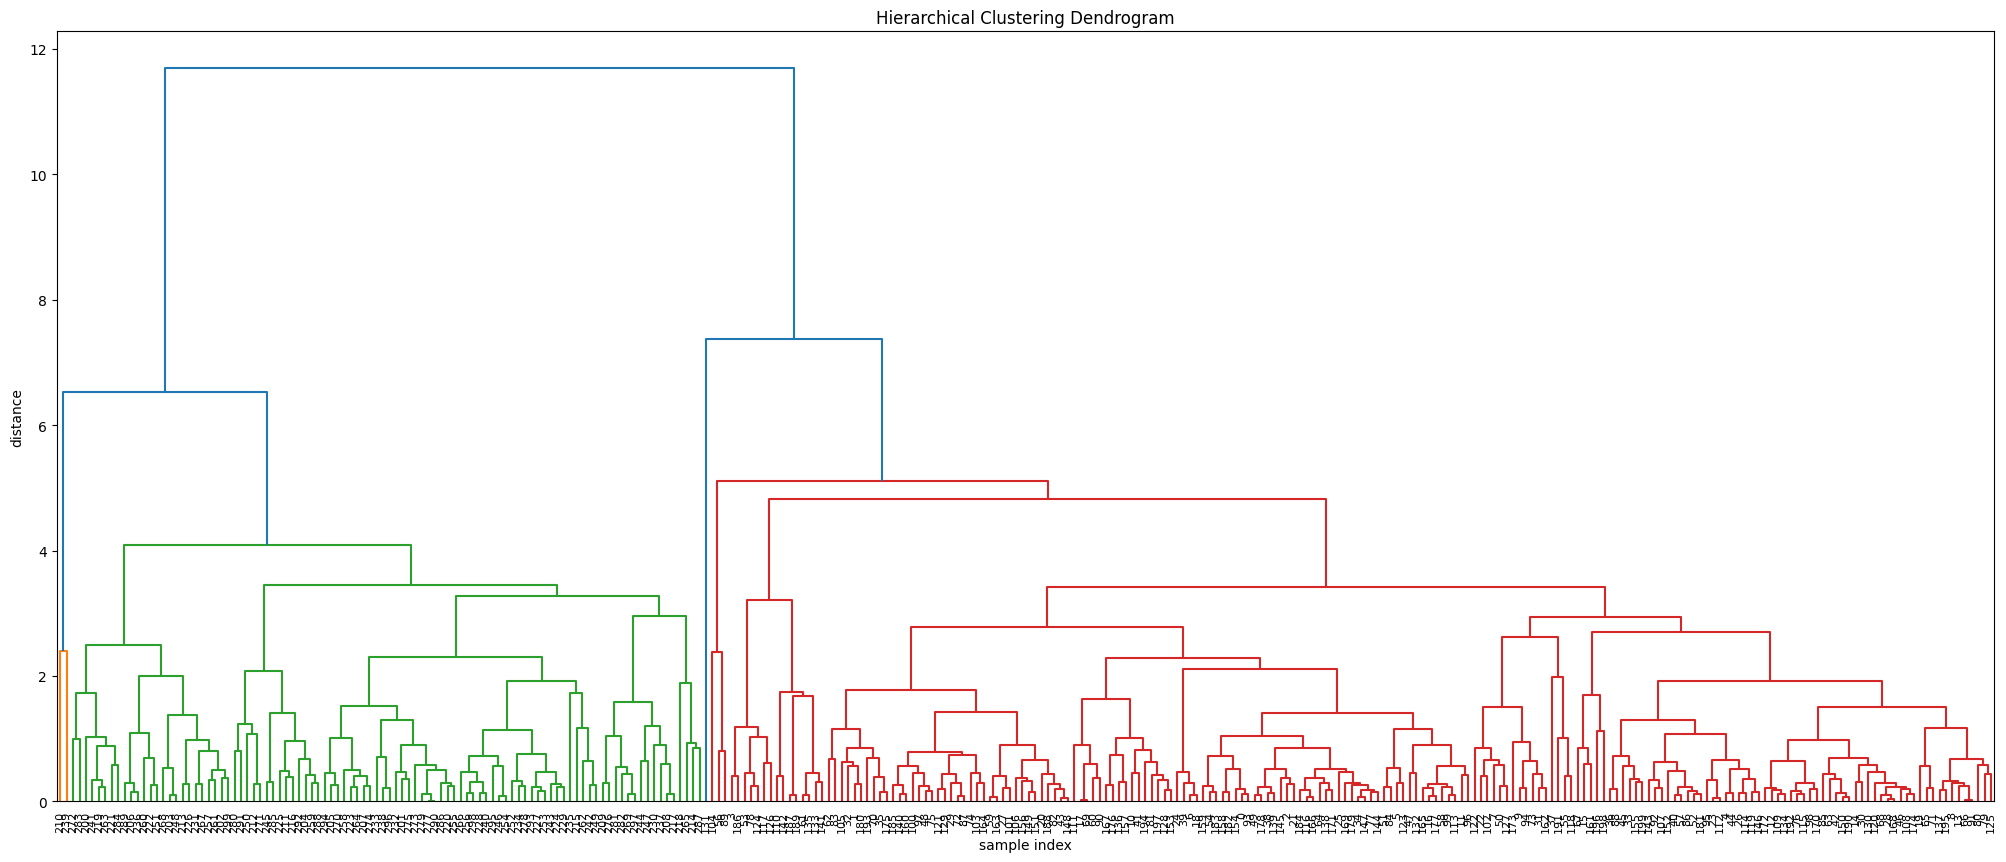

In [27]:
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(Z, leaf_rotation=90, leaf_font_size=8, color_threshold=6)
plt.show()

### Smaller dataset — a closer look at individual point merges

With 300 points, the dendrogram gets crowded. Here we repeat the exercise with a smaller dataset (75 points) so you can see individual sample indices at the leaves and get a clearer picture of how the merging process works. The truncated dendrogram views that follow collapse smaller sub-trees to keep the picture manageable.

(75, 2)


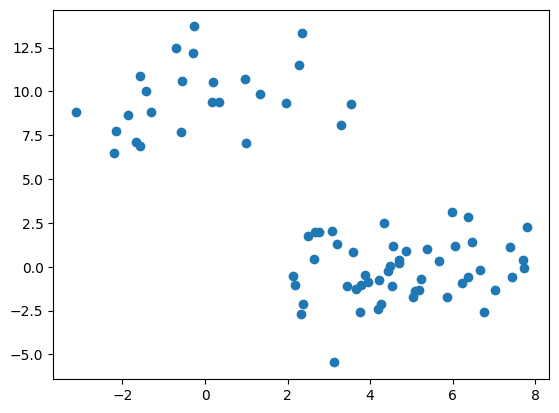

In [28]:
np.random.seed(42)
a = np.random.multivariate_normal([5, 0], [[3, 1], [1, 4]], size=[50,])
b = np.random.multivariate_normal([0, 10], [[3, 1], [1, 4]], size=[25,])
X = np.concatenate((a, b),)
print(X.shape)
plt.scatter(X[:,0], X[:,1])
plt.show()

In [29]:
Z = linkage(X, 'average')
Z.shape

(74, 4)

In [30]:
Z[0]

array([ 6.     , 18.     ,  0.10092,  2.     ])

In [31]:
Z[1]

array([ 4.     , 44.     ,  0.13721,  2.     ])

In [32]:
Z[:20]

array([[ 6.     , 18.     ,  0.10092,  2.     ],
       [ 4.     , 44.     ,  0.13721,  2.     ],
       [52.     , 57.     ,  0.17172,  2.     ],
       [38.     , 49.     ,  0.2022 ,  2.     ],
       [65.     , 71.     ,  0.2168 ,  2.     ],
       [14.     , 46.     ,  0.22489,  2.     ],
       [ 2.     , 21.     ,  0.27484,  2.     ],
       [39.     , 75.     ,  0.29892,  3.     ],
       [28.     , 42.     ,  0.30441,  2.     ],
       [ 8.     , 13.     ,  0.31169,  2.     ],
       [33.     , 45.     ,  0.36733,  2.     ],
       [26.     , 76.     ,  0.4046 ,  3.     ],
       [25.     , 34.     ,  0.40936,  2.     ],
       [30.     , 80.     ,  0.4174 ,  3.     ],
       [ 1.     , 32.     ,  0.43788,  2.     ],
       [20.     , 43.     ,  0.45119,  2.     ],
       [10.     , 41.     ,  0.45219,  2.     ],
       [24.     , 82.     ,  0.46023,  4.     ],
       [ 5.     , 88.     ,  0.46259,  4.     ],
       [78.     , 81.     ,  0.48158,  4.     ]])

<Figure size 2500x1000 with 0 Axes>

Text(0.5, 1.0, 'Hierarchical Clustering Dendrogram')

Text(0.5, 0, 'sample index')

Text(0, 0.5, 'distance')

{'icoord': [[35.0, 35.0, 45.0, 45.0],
  [25.0, 25.0, 40.0, 40.0],
  [15.0, 15.0, 32.5, 32.5],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [23.75, 23.75, 62.5, 62.5],
  [5.0, 5.0, 43.125, 43.125],
  [95.0, 95.0, 105.0, 105.0],
  [85.0, 85.0, 100.0, 100.0],
  [115.0, 115.0, 125.0, 125.0],
  [135.0, 135.0, 145.0, 145.0],
  [155.0, 155.0, 165.0, 165.0],
  [185.0, 185.0, 195.0, 195.0],
  [175.0, 175.0, 190.0, 190.0],
  [160.0, 160.0, 182.5, 182.5],
  [140.0, 140.0, 171.25, 171.25],
  [120.0, 120.0, 155.625, 155.625],
  [215.0, 215.0, 225.0, 225.0],
  [205.0, 205.0, 220.0, 220.0],
  [235.0, 235.0, 245.0, 245.0],
  [212.5, 212.5, 240.0, 240.0],
  [137.8125, 137.8125, 226.25, 226.25],
  [92.5, 92.5, 182.03125, 182.03125],
  [24.0625, 24.0625, 137.265625, 137.265625],
  [265.0, 265.0, 275.0, 275.0],
  [305.0, 305.0, 315.0, 315.0],
  [295.0, 295.0, 310.0, 310.0],
  [285.0, 285.0, 302.5, 302.5],
  [270.0, 270.0, 293.75, 293.75],
  [345.0, 345.0, 355.0, 355.0],
  [335.0, 335.0, 350.0

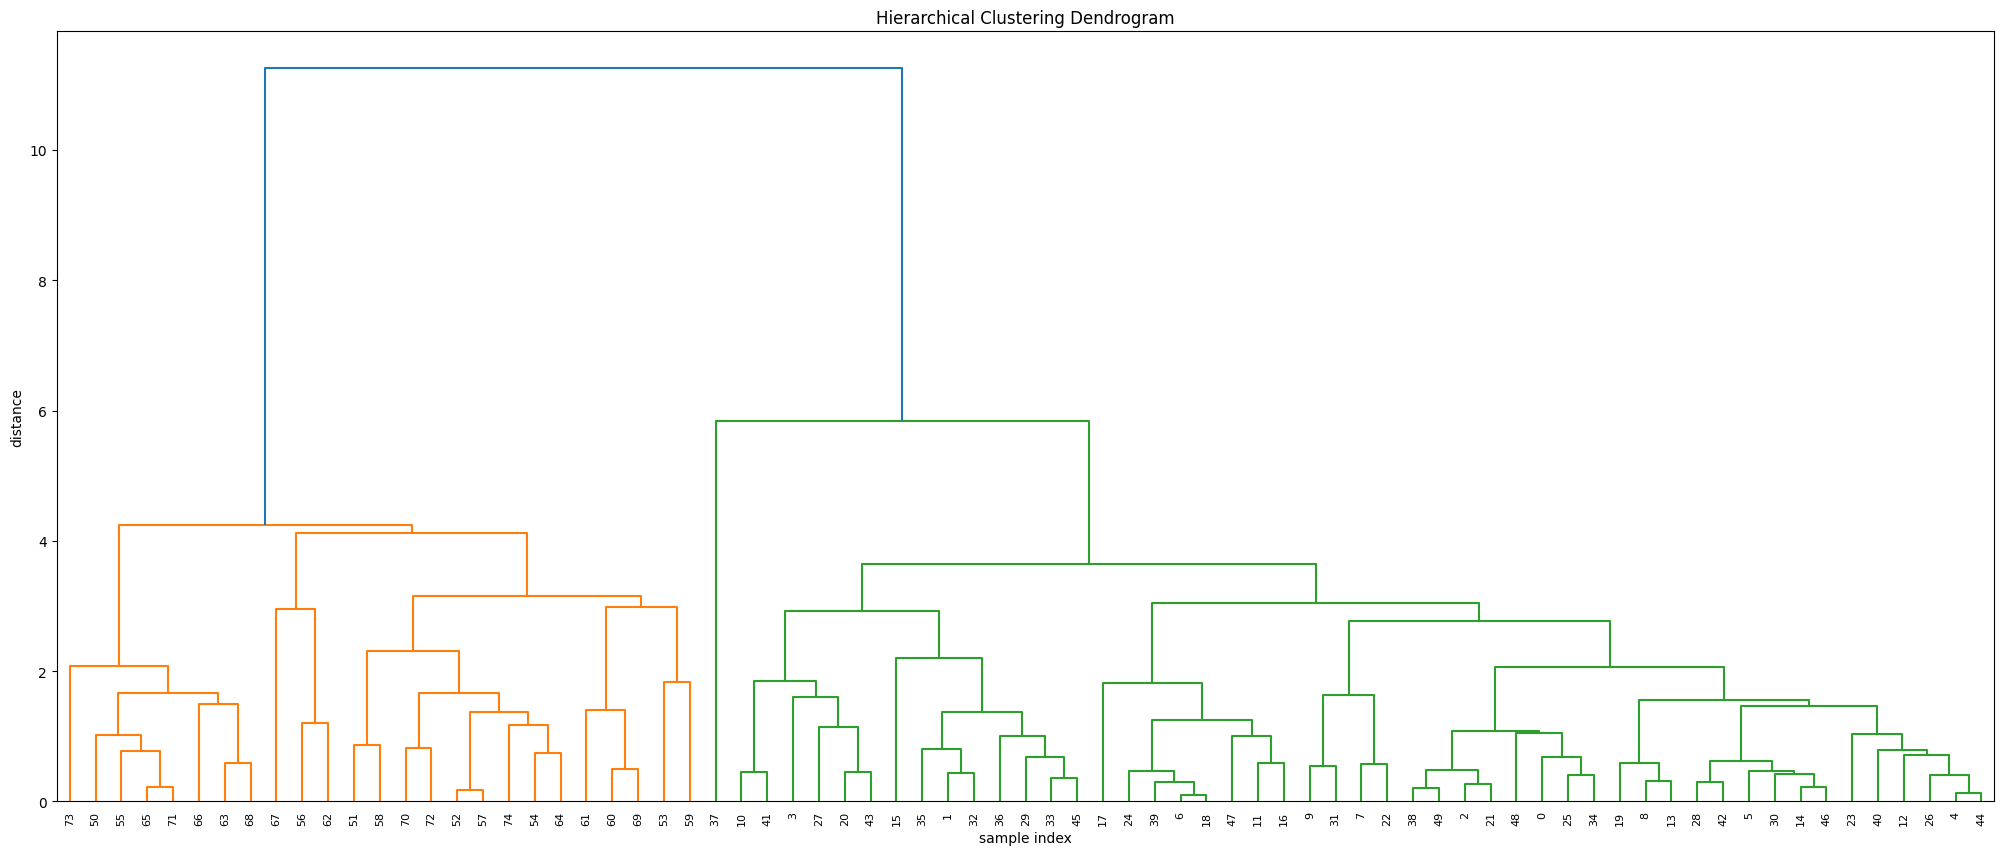

In [33]:
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.show()

<Figure size 2500x1000 with 0 Axes>

Text(0.5, 1.0, 'Hierarchical Clustering Dendrogram')

Text(0.5, 0, 'sample index')

Text(0, 0.5, 'distance')

{'icoord': [[35.0, 35.0, 45.0, 45.0],
  [25.0, 25.0, 40.0, 40.0],
  [15.0, 15.0, 32.5, 32.5],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [23.75, 23.75, 62.5, 62.5],
  [5.0, 5.0, 43.125, 43.125],
  [95.0, 95.0, 105.0, 105.0],
  [85.0, 85.0, 100.0, 100.0],
  [115.0, 115.0, 125.0, 125.0],
  [135.0, 135.0, 145.0, 145.0],
  [155.0, 155.0, 165.0, 165.0],
  [185.0, 185.0, 195.0, 195.0],
  [175.0, 175.0, 190.0, 190.0],
  [160.0, 160.0, 182.5, 182.5],
  [140.0, 140.0, 171.25, 171.25],
  [120.0, 120.0, 155.625, 155.625],
  [215.0, 215.0, 225.0, 225.0],
  [205.0, 205.0, 220.0, 220.0],
  [235.0, 235.0, 245.0, 245.0],
  [212.5, 212.5, 240.0, 240.0],
  [137.8125, 137.8125, 226.25, 226.25],
  [92.5, 92.5, 182.03125, 182.03125],
  [24.0625, 24.0625, 137.265625, 137.265625],
  [265.0, 265.0, 275.0, 275.0],
  [305.0, 305.0, 315.0, 315.0],
  [295.0, 295.0, 310.0, 310.0],
  [285.0, 285.0, 302.5, 302.5],
  [270.0, 270.0, 293.75, 293.75],
  [345.0, 345.0, 355.0, 355.0],
  [335.0, 335.0, 350.0

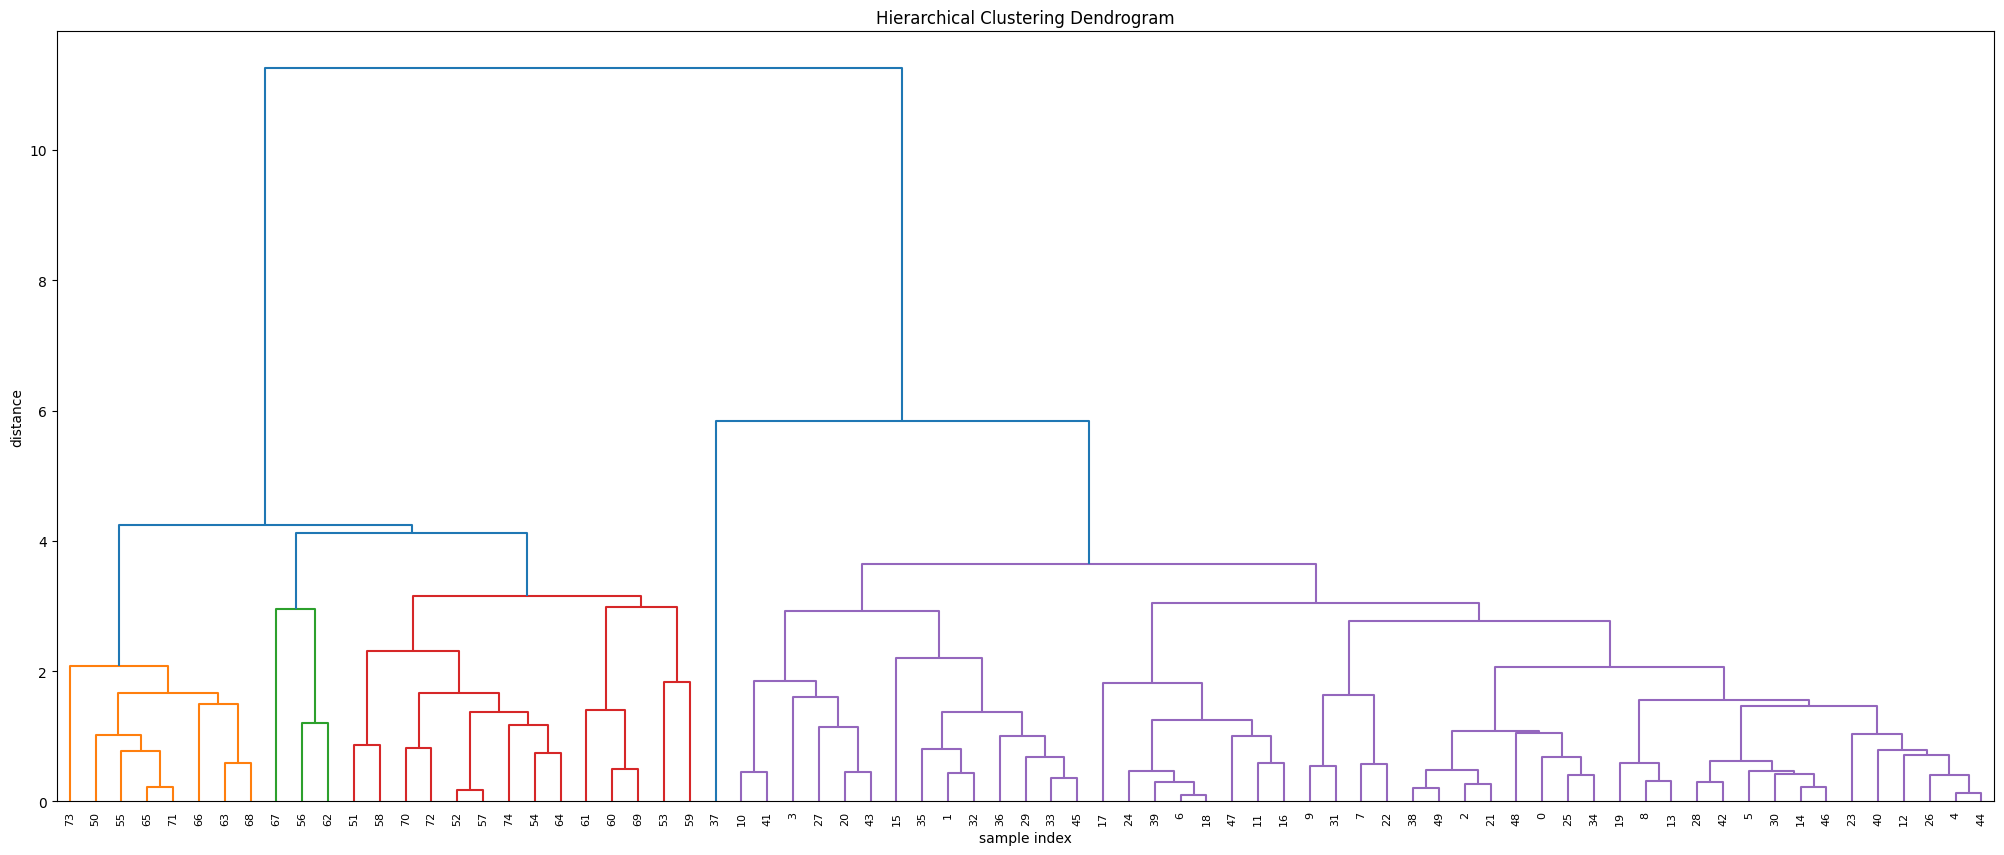

In [34]:
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(Z, leaf_rotation=90, leaf_font_size=8, color_threshold=4)
plt.show()

Text(0.5, 1.0, 'Hierarchical Clustering Dendrogram (truncated)')

Text(0.5, 0, 'sample index')

Text(0, 0.5, 'distance')

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [45.0, 45.0, 55.0, 55.0],
  [35.0, 35.0, 50.0, 50.0],
  [20.0, 20.0, 42.5, 42.5],
  [5.0, 5.0, 31.25, 31.25],
  [75.0, 75.0, 85.0, 85.0],
  [105.0, 105.0, 115.0, 115.0],
  [95.0, 95.0, 110.0, 110.0],
  [80.0, 80.0, 102.5, 102.5],
  [65.0, 65.0, 91.25, 91.25],
  [18.125, 18.125, 78.125, 78.125]],
 'dcoord': [[0.0, 2.959041395392501, 2.959041395392501, 0.0],
  [0.0, 2.980488834762979, 2.980488834762979, 0.0],
  [0.0, 3.1525704487706663, 3.1525704487706663, 2.980488834762979],
  [2.959041395392501,
   4.122731009989154,
   4.122731009989154,
   3.1525704487706663],
  [0.0, 4.241133683258102, 4.241133683258102, 4.122731009989154],
  [0.0, 2.918231053490336, 2.918231053490336, 0.0],
  [0.0, 2.768508378570646, 2.768508378570646, 0.0],
  [0.0, 3.0474953826416997, 3.0474953826416997, 2.768508378570646],
  [2.918231053490336, 3.65304604256842, 3.65304604256842, 3.0474953826416997],
  [0.0, 5.83687783444232, 5.83687783444232, 3.65304604256842],
  [4.241133

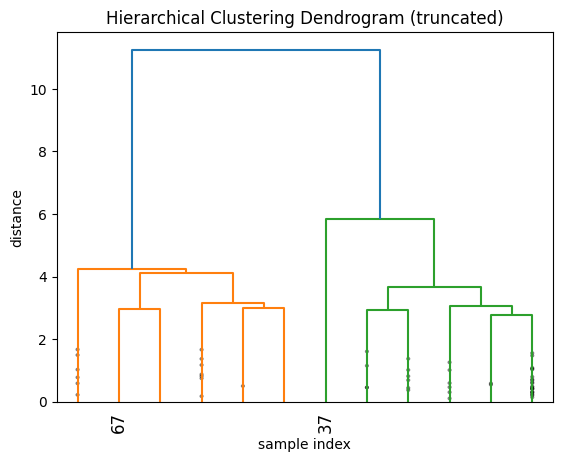

In [35]:
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(Z, truncate_mode='lastp', p=12, show_leaf_counts=False, leaf_rotation=90, leaf_font_size=12, show_contracted=True)
plt.show()

Text(0.5, 1.0, 'Hierarchical Clustering Dendrogram (truncated)')

Text(0.5, 0, 'sample index or (cluster size)')

Text(0, 0.5, 'distance')

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [45.0, 45.0, 55.0, 55.0],
  [35.0, 35.0, 50.0, 50.0],
  [20.0, 20.0, 42.5, 42.5],
  [5.0, 5.0, 31.25, 31.25],
  [75.0, 75.0, 85.0, 85.0],
  [105.0, 105.0, 115.0, 115.0],
  [95.0, 95.0, 110.0, 110.0],
  [80.0, 80.0, 102.5, 102.5],
  [65.0, 65.0, 91.25, 91.25],
  [18.125, 18.125, 78.125, 78.125]],
 'dcoord': [[0.0, 2.959041395392501, 2.959041395392501, 0.0],
  [0.0, 2.980488834762979, 2.980488834762979, 0.0],
  [0.0, 3.1525704487706663, 3.1525704487706663, 2.980488834762979],
  [2.959041395392501,
   4.122731009989154,
   4.122731009989154,
   3.1525704487706663],
  [0.0, 4.241133683258102, 4.241133683258102, 4.122731009989154],
  [0.0, 2.918231053490336, 2.918231053490336, 0.0],
  [0.0, 2.768508378570646, 2.768508378570646, 0.0],
  [0.0, 3.0474953826416997, 3.0474953826416997, 2.768508378570646],
  [2.918231053490336, 3.65304604256842, 3.65304604256842, 3.0474953826416997],
  [0.0, 5.83687783444232, 5.83687783444232, 3.65304604256842],
  [4.241133

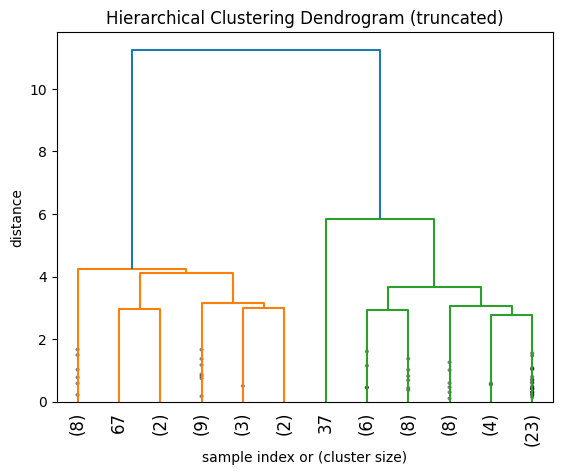

In [36]:
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('sample index or (cluster size)')
plt.ylabel('distance')
dendrogram(Z, truncate_mode='lastp', p=12, leaf_rotation=90., leaf_font_size=12., show_contracted=True)
plt.show()

## Summary and practical decisions

Both K-means and hierarchical clustering are useful, but each requires choices that significantly affect the outcome. Here are the main things to think about when applying either method:

**For K-means:**
- Should the data be standardized? If one feature has much larger values than another, it will dominate the distance calculation and effectively be the only thing that matters. Standardizing puts all features on equal footing.
- How many clusters (K) should you use? The elbow method gives a starting point, but there is rarely a single objectively correct answer.

**For hierarchical clustering:**
- Which linkage criterion should you use? Average and complete linkage tend to produce more balanced dendrograms.
- What dissimilarity measure should you use? Euclidean distance is the default, but sometimes correlation-based distance is more appropriate (for example, when clustering shoppers, you may care more about the pattern of what they buy than the raw quantities).
- Where should you cut the dendrogram?

For all of these questions, there is no single right answer. The best approach is to try several options and look for solutions that reveal something interesting and interpretable about the data.